# Lecture 4 — Deep Neural Networks
## Lab Notebook · Deep Learning · UCU

---

### Overview
In Notebook 2, we explored **shallow neural networks** — networks with a single hidden layer. We saw that increasing the width $D$ improves performance, but with diminishing returns. The Universal Approximation Theorem tells us that a shallow network *can* approximate any function, but it doesn't say it will do so *efficiently*.

In this notebook, we take the next step: **deep neural networks** — networks with multiple hidden layers. From Lecture 4, we know that a deep network with $K$ layers of width $D$ can produce up to $(D+1)^K$ linear regions, compared to only $D+1$ for a shallow network. This exponential increase in expressiveness is the key advantage of depth.

By the end of this notebook, you will:
1. **Compose** two shallow networks and visualize the "folding" effect on the input space
2. **Inspect** network architectures using `torchinfo` — counting parameters and understanding layer shapes
3. **Design** deep architectures under a fixed parameter budget and compare their performance
4. **Visualize** learned representations using PCA to understand what depth does internally
5. **Evaluate** whether depth helps equally on structured (images) vs. tabular data

### Useful References

| Resource | Link |
|----------|------|
| PyTorch `nn.Module` | [pytorch.org/docs/stable/generated/torch.nn.Module.html](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) |
| PyTorch `nn.Sequential` | [pytorch.org/docs/stable/generated/torch.nn.Sequential.html](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html) |
| `torchinfo` documentation | [github.com/TylerYep/torchinfo](https://github.com/TylerYep/torchinfo) |
| FashionMNIST dataset | [github.com/zalandoresearch/fashion-mnist](https://github.com/zalandoresearch/fashion-mnist) |
| UCU Deep Learning — Lecture 4 notes | [../../lectures/lecture 4/notes.md](../../lectures/lecture%204/notes.md) |
| *Understanding Deep Learning* — Prince (2023) | Chapter 4 |

In [7]:
# Setup — run this cell first
try:
    import google.colab
    IN_COLAB = True
    %pip install -q torchinfo
except ImportError:
    IN_COLAB = False

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
from torchinfo import summary
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# UCU color palette
C1, C2, C3, C4, C5 = '#19326E', '#50ACB0', '#CD742A', '#A3477F', '#907FAB'
C6, C7 = '#4294CC', '#89A943'

Using device: cpu


---

## 1. Composing Networks: The Folding Intuition

Before working with deep networks on real data, let's build intuition with a simple 1D example from Lecture 4.

The idea: take two shallow networks and **compose** them — the output of the first becomes the input of the second. Each shallow network with 3 hidden ReLU units produces a piecewise linear function with up to 4 linear regions. When we compose them, the first network **"folds"** the input space, and the second network applies its function to the folded space. The result: the second network's effect is **duplicated** at every fold, dramatically increasing the number of linear regions.

This is the fundamental insight behind why depth is so powerful.

In [8]:
# Two pre-defined shallow networks (1D input -> 3 hidden ReLU -> 1D output)
# Each is defined by its parameters: biases (t_0) and weights (t_1) for hidden units,
# plus output weights (p) and bias (p0).

def shallow_net_1d(x, params):
    """Forward pass of a shallow network with 3 ReLU hidden units.
    
    Args:
        x: numpy array of inputs
        params: dict with keys t10, t11, t20, t21, t30, t31, p0, p1, p2, p3
    Returns:
        output y = p0 + p1*h1 + p2*h2 + p3*h3
    """
    h1 = np.maximum(0, params['t10'] + params['t11'] * x)
    h2 = np.maximum(0, params['t20'] + params['t21'] * x)
    h3 = np.maximum(0, params['t30'] + params['t31'] * x)
    return params['p0'] + params['p1']*h1 + params['p2']*h2 + params['p3']*h3

# Network 1: creates a "folding" function
net1_params = {
    't10': -1.0, 't11':  2.0,
    't20':  0.0, 't21': -3.0,
    't30':  1.0, 't31':  1.5,
    'p0': 0.0, 'p1': 1.0, 'p2': 1.0, 'p3': -0.8
}

# Network 2: applied to the folded output
net2_params = {
    't10': -0.5, 't11':  1.5,
    't20':  0.3, 't21': -1.2,
    't30': -0.2, 't31':  0.8,
    'p0': 0.1, 'p1': 0.8, 'p2': -0.6, 'p3': 0.5
}

x = np.linspace(-1, 1, 500)

### Exercise 1.1 — Compose the two networks

Compute the **composed output** by feeding the output of Network 1 into Network 2. This is a single line of code — think about what "composition" means mathematically.

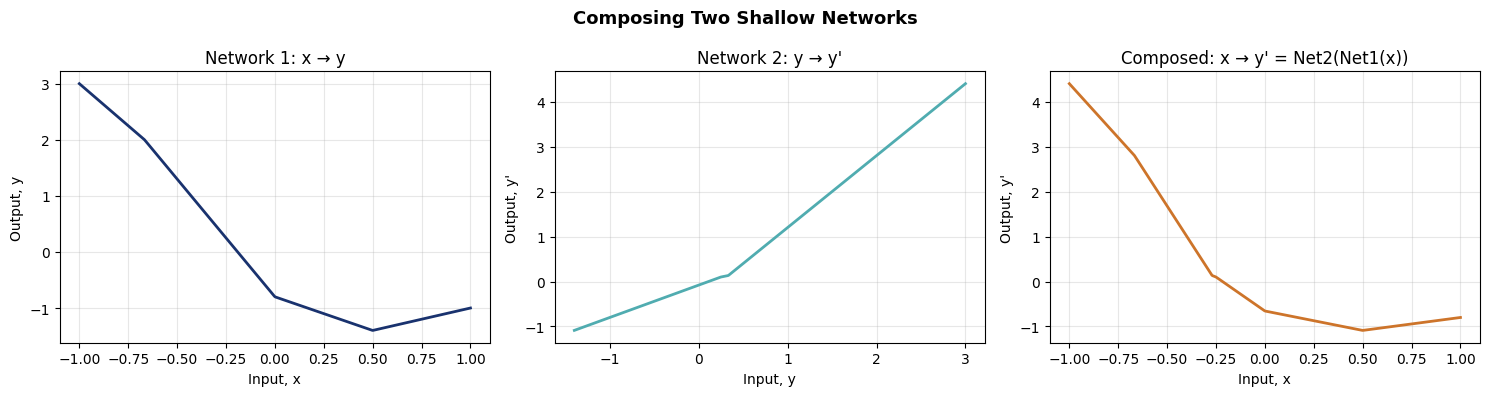

In [9]:
# Compute outputs
y_net1 = shallow_net_1d(x, net1_params)     # Network 1: x -> y

# YOUR CODE HERE: compose the networks — feed net1's output into net2
y_composed = shallow_net_1d(y_net1, net2_params)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x, y_net1, color=C1, linewidth=2)
axes[0].set_xlabel('Input, x'); axes[0].set_ylabel('Output, y')
axes[0].set_title('Network 1: x → y'); axes[0].grid(True, alpha=0.3)

# Also show net2 applied to a uniform range for reference
y_range = np.linspace(y_net1.min(), y_net1.max(), 500)
y_net2_ref = shallow_net_1d(y_range, net2_params)
axes[1].plot(y_range, y_net2_ref, color=C2, linewidth=2)
axes[1].set_xlabel('Input, y'); axes[1].set_ylabel("Output, y'")
axes[1].set_title("Network 2: y → y'"); axes[1].grid(True, alpha=0.3)

axes[2].plot(x, y_composed, color=C3, linewidth=2)
axes[2].set_xlabel('Input, x'); axes[2].set_ylabel("Output, y'")
axes[2].set_title("Composed: x → y' = Net2(Net1(x))"); axes[2].grid(True, alpha=0.3)

plt.suptitle('Composing Two Shallow Networks', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 1.1** — Look at the three plots above:
>
> 1. Count the number of linear regions in Network 1's output and in Network 2's output. How many linear regions does the composed network produce?
> 2. The first network "folds" the input space — multiple values of $x$ map to the same $y$. What happens to Network 2's function at those folded points?
> 3. From the lecture: a shallow network with $D$ hidden units produces at most $D+1$ linear regions. What's the maximum for two composed networks with $D_1$ and $D_2$ hidden units?
>

> *Your answer here:*
>
> 1. Produce 4 regiones lineales. La Red 2 tiene 4 regiones (hay que ver muy de cerca el pliegue con forma de silla). La red compuesta (gráfico derecho) produce 6 regiones lineales visibles, menos que el máximo teórico de 16, porque algunas unidades ReLU de las redes están inactivas en este rango de entrada y no todas las "pliegues" se activan.
>
> 2. La Red 1 tiene un pliegue claro cerca de x=0.5 donde alcanza su mínimo y rebota. En ese pliegue, la función de la Red 2 queda reflejada: en la salida compuesta se puede ver cómo el patrón de la Red 2 se repite simétricamente alrededor de ese punto, creando quiebres adicionales que ninguna red produciría sola.
> 
> 3. El máximo de regiones es (D1 + 1) × (D2 + 1). Con D1 = D2 = 3: hasta 16 regiones lineales. En general para K capas de ancho D: (D+1)^K.


---

## 2. Inspecting Architectures with `torchinfo`

In Lecture 4, we derived formulas for counting parameters in deep networks. In practice, you don't compute these by hand — you use tools. [`torchinfo`](https://github.com/TylerYep/torchinfo) is a lightweight library that gives you a complete summary of any PyTorch model: layer types, output shapes, and parameter counts.

This is the kind of tool you'll use constantly when designing and debugging architectures.

In [10]:
# Quick demo: torchinfo on a simple model
demo_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

# summary() takes the model and an example input size
summary(demo_model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Flatten: 1-1                           [1, 784]                  --
├─Linear: 1-2                            [1, 128]                  100,480
├─ReLU: 1-3                              [1, 128]                  --
├─Linear: 1-4                            [1, 10]                   1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.10
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.41
Estimated Total Size (MB): 0.41

### Exercise 2.1 — Define and compare three architectures

Define three `nn.Sequential` models for FashionMNIST classification (input: 1×28×28, output: 10 classes). All should start with `nn.Flatten()` and use `nn.ReLU()` activations between linear layers.

| Name | Architecture |
|------|-------------|
| **Shallow** | 784 → 256 → 10 |
| **Medium** | 784 → 64 → 64 → 10 |
| **Deep** | 784 → 32 → 32 → 32 → 32 → 10 |

In [ ]:
# YOUR CODE HERE: define three nn.Sequential models
# shallow_model = nn.Sequential(...)
# medium_model  = nn.Sequential(...)
# deep_model    = nn.Sequential(...)
shallow_model = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))
medium_model = nn.Sequential(nn.Flatten(), nn.Linear(784, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 10))
deep_model = nn.Sequential(nn.Flatten(), nn.Linear(784, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 10))

In [12]:
# Inspect each model with torchinfo
print("=" * 60)
print("SHALLOW (784 → 256 → 10)")
print("=" * 60)
print(summary(shallow_model, input_size=(1, 1, 28, 28), verbose=0))

print("\n" + "=" * 60)
print("MEDIUM (784 → 64 → 64 → 10)")
print("=" * 60)
print(summary(medium_model, input_size=(1, 1, 28, 28), verbose=0))

print("\n" + "=" * 60)
print("DEEP (784 → 32 → 32 → 32 → 32 → 10)")
print("=" * 60)
print(summary(deep_model, input_size=(1, 1, 28, 28), verbose=0))

SHALLOW (784 → 256 → 10)
Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Flatten: 1-1                           [1, 784]                  --
├─Linear: 1-2                            [1, 256]                  200,960
├─ReLU: 1-3                              [1, 256]                  --
├─Linear: 1-4                            [1, 10]                   2,570
Total params: 203,530
Trainable params: 203,530
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.20
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.81
Estimated Total Size (MB): 0.82

MEDIUM (784 → 64 → 64 → 10)
Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Flatten: 1-1                           [1, 784]                  --
├─Linear: 1-2                            [1, 64]                   50,2

### Exercise 2.2 — Fill in the comparison table

Using the `torchinfo` output above, complete this table:

| Model | Total Parameters | Max Linear Regions (lecture formula) |
|-------|-----------------|--------------------------------------|
| Shallow (1 hidden, D=256) | *203.530* | *257* |
| Medium (2 hidden, D=64) | *55.050* | *4.225 (65x65)* |
| Deep (4 hidden, D=32) | *28.618* | *1.185.921 (33x33x33)* |



> **Hint:** From Lecture 4, a network with $K$ hidden layers of width $D$ can produce up to $(D+1)^K$ linear regions (for a 1D input). For multi-dimensional inputs the bound is more complex, but the exponential relationship with depth still holds.

> **Question 2.1** — Looking at your table:
>
> 1. Which model has the most parameters?
> 2. Which model has the most linear regions?
> 3. Does having more parameters guarantee more expressiveness? Explain using the numbers you computed.
>

> *Your answer here:*
>
> 1. La red Shallow tiene con diferencia el mayor número de parámetros 203K. 
>
> 2. La red Deep tiene el mayor número de regiones lineales por un margen enorme (aprox. 1.2 millones).
>
> 3. No, tener más parámetros no garantiza más expresividad. La red superficial usa 7 veces más parámetros que la profunda y sin embargo solo puede generar 257 regiones lineales. La red profunda alcanza más de un millón de regiones con una fracción de los parámetros. La profundidad es un camino mucho más eficiente hacia la expresividad que el ancho.

---

## 3. Depth vs. Width on FashionMNIST

Now for the main experiment. In Notebook 2, we explored how **width** (number of hidden units) affects a shallow network's performance. Now we ask a different question: **given a fixed parameter budget, is it better to go wide or deep?**

From Lecture 4, we expect deeper networks to be more expressive per parameter. Let's test this empirically.

In [13]:
# Load FashionMNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

100.0%
100.0%
100.0%
100.0%


Training samples : 60000
Test samples     : 10000


In [14]:
# Training utilities (same pattern as Notebook 2)

def train_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch. Returns (avg_loss, accuracy %)."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns (avg_loss, accuracy %)."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            total_loss += loss.item()
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / len(loader), 100. * correct / total

### Exercise 3.1 — Design architectures under a parameter budget

Your task: design **four** `nn.Sequential` architectures for FashionMNIST, all with **approximately 25,000 parameters** (~25K). Each must start with `nn.Flatten()` and use ReLU activations.

| Name | Hidden Layers | Width per layer | Target params |
|------|:------------:|:---------------:|:-------------:|
| **arch_1L** | 1 | *you decide* | ~25K |
| **arch_2L** | 2 | *you decide* | ~25K |
| **arch_4L** | 4 | *you decide* | ~25K |
| **arch_8L** | 8 | *you decide* | ~25K |

> **Hint:** For a network with input $D_i = 784$, hidden layers of width $D$, and output $D_o = 10$:
> - 1 hidden layer: params $\approx 784 \times D + D + D \times 10 + 10$
> - For deeper networks, intermediate layers contribute $D \times D + D$ params each
>
> Use `torchinfo.summary()` to verify your designs are close to 25K. They don't need to be exact — within ±2K is fine.

**Important:** Store all four models in a dictionary called `architectures` so the training cell below can iterate over them.

In [27]:
# YOUR CODE HERE: design four architectures with ~25K parameters each

# arch_1L = nn.Sequential(...)  # 1 hidden layer
# arch_2L = nn.Sequential(...)  # 2 hidden layers
# arch_4L = nn.Sequential(...)  # 4 hidden layers
# arch_8L = nn.Sequential(...)  # 8 hidden layers

def make_mlp(hidden_sizes):
    layers = [nn.Flatten()]
    in_dim = 784
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU()]
        in_dim = h
    layers.append(nn.Linear(in_dim, 10))
    return nn.Sequential(*layers)

arch_1L = make_mlp([30]) 
# 784×30 + 30   (primera capa) + 30×10 + 10  (salida)
# = 23,520 + 30 + 300 + 10 = 23,860 

arch_2L = make_mlp([30, 30]) 
# 784×30 + 30   (primera capa) + 30×30 + 30  (capa oculta 2) + 30×10 + 10  (salida)
# = 23,520 + 30 + 900 + 30 + 300 + 10 = 24,790 

arch_4L = make_mlp([28, 28, 28, 28])
# 784×28 + 28 (primera capa) + (28×28 + 28)×3 (capa oculta 2-4) + 28×10 + 10 (salida)
# = 21,952 + 28 + 2,436 + 290 = 24,706 

arch_8L = make_mlp([26, 26, 26, 26, 26, 26, 26, 26]) 
# 784×26 + 26   (primera capa) + (26×26 + 26)×7  (capas ocultas 2-8) + 26×10 + 10  (salida)
# = 20,384 + 26 + 4,914 + 270 = 25,594 

# Store in a dictionary for the training loop
architectures = {
    '1 layer':  arch_1L,
    '2 layers': arch_2L,
    '4 layers': arch_4L,
    '8 layers': arch_8L,
}

In [28]:
# Verify parameter counts with torchinfo
for name, model in architectures.items():
    info = summary(model, input_size=(1, 1, 28, 28), verbose=0)
    print(f"{name:>10s}  |  {info.total_params:,} parameters")

   1 layer  |  23,860 parameters
  2 layers  |  24,790 parameters
  4 layers  |  24,706 parameters
  8 layers  |  25,594 parameters


### Exercise 3.2 — Train and compare

Train all four architectures and collect their training curves. You can choose the number of epochs — we suggest **10** as a starting point, but feel free to increase if you think some architectures need more time to converge.

The training code is provided below — just set `NUM_EPOCHS`.

In [49]:
# YOUR CODE HERE: choose the number of epochs
# NUM_EPOCHS = ...
NUM_EPOCHS = 25

criterion = nn.CrossEntropyLoss()
colors = [C1, C2, C3, C4]

# Store results for each architecture
results = {}

for (name, model), color in zip(architectures.items(), colors):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    
    for epoch in range(NUM_EPOCHS):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
    
    results[name] = history
    print(f"{name:>10s}  |  Train: {tr_acc:.1f}%  |  Test: {te_acc:.1f}%")

# Update the architectures dict with trained models (they're already updated in-place)
print(f"\nAll models trained for {NUM_EPOCHS} epochs.")

   1 layer  |  Train: 93.7%  |  Test: 86.0%
  2 layers  |  Train: 94.4%  |  Test: 86.8%
  4 layers  |  Train: 93.6%  |  Test: 86.9%
  8 layers  |  Train: 92.2%  |  Test: 86.2%

All models trained for 25 epochs.


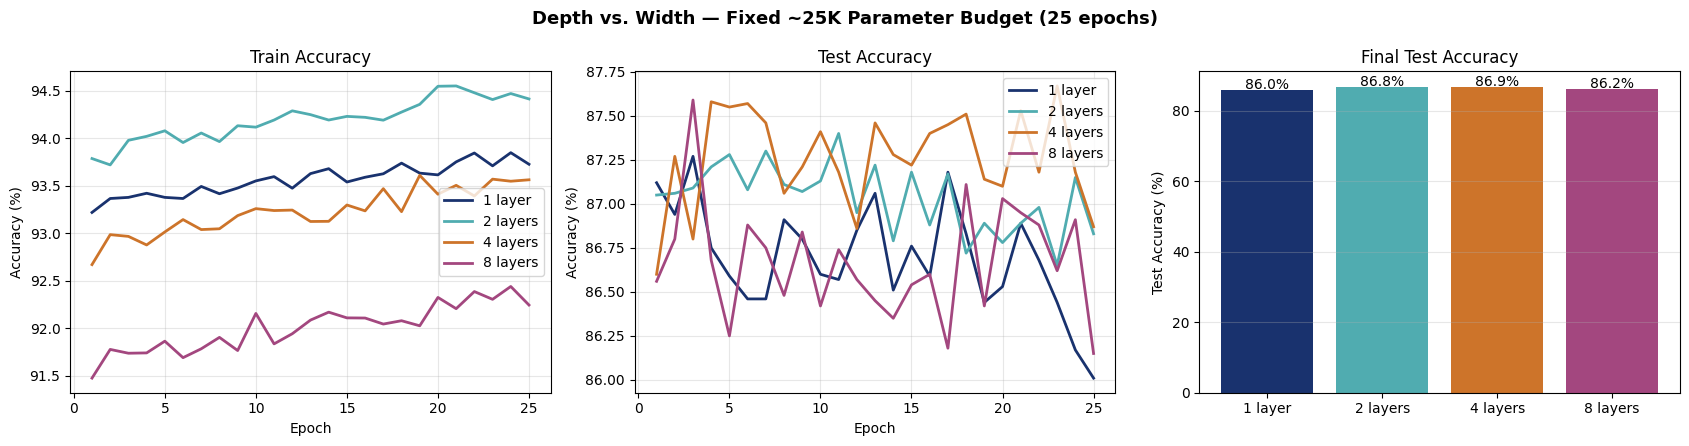

In [50]:
# Visualization: accuracy curves + final accuracy comparison
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

epochs_range = range(1, NUM_EPOCHS + 1)

# Train accuracy curves
for (name, hist), color in zip(results.items(), colors):
    axes[0].plot(epochs_range, hist['train_acc'], color=color, linewidth=2, label=name)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Train Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Test accuracy curves
for (name, hist), color in zip(results.items(), colors):
    axes[1].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=name)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Test Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Final test accuracy bar chart
names = list(results.keys())
final_test_accs = [results[n]['test_acc'][-1] for n in names]
bars = axes[2].bar(names, final_test_accs, color=colors)
axes[2].set_ylabel('Test Accuracy (%)')
axes[2].set_title('Final Test Accuracy')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, final_test_accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.1f}%', ha='center', fontsize=10)

plt.suptitle(f'Depth vs. Width — Fixed ~25K Parameter Budget ({NUM_EPOCHS} epochs)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 3.1** — Analyzing the depth experiment:
>
> 1. Which architecture achieved the best **test accuracy**? Does this match the lecture's prediction about depth efficiency?
> 2. Which architecture **converged fastest** (reached high accuracy in fewer epochs)? Which was slowest?
> 3. Did any deep architecture perform **worse** than the shallow one? If so, why might that happen? (Think about what difficulties arise when training very deep networks.)
> 4. Look at the **train-test gap** for each architecture. Which model overfits the most? Which generalizes best?
>


> *Your answer here:*
> **Respuesta Final con 25 Epoch**
> 1. La arquitectura de 4 capas logró el mejor test accuracy final con 86.9%, seguida de cerca por 2 capas (86.8%). La profundidad moderada supera a la red puramente ancha (1 capa: 86.0%). Sin embargo, las diferencias son pequeñas y las curvas de test oscilan tanto que sería arriesgado sacar conclusiones muy fuertes, en otra época la de 2 capas podría haber ganado fácilmente.
>
> 2. Las redes de 2 y 4 capas convergieron más rápido, alcanzando accuracies altos desde las primeras épocas con curvas de entrenamiento estables. La de 8 capas fue claramente la más lenta, representando el problema de gradientes que se desvanecen en redes muy profundas sin técnicas auxiliares.
>
> 3. Sí, la red de 8 capas (86.2%) rinde peor que la de 4 capas y similar a la de 2, a pesar de haber entrenado durante 25 épocas. Con ReLU simples y sin batch normalization ni conexiones residuales, los gradientes se vuelven muy pequeños antes de llegar a las primeras capas, que apenas se actualizan. Además, aunque la anchura de 26 es mejor que los 17 de la versión anterior, sigue siendo un cuello de botella considerable distribuido a lo largo de 8 capas.
>
> 4. Todas las arquitecturas muestran una brecha train-test considerable: la de 2 capas tiene el mayor sobreajuste con 94.5% train vs 86.8% test (brecha de 7.7 puntos), seguida de la de 1 capa (93.8% vs 86.0%, brecha de 7.8 puntos). La de 8 capas paradójicamente tiene la menor brecha absoluta (92.2% vs 86.2%, 6 puntos) no porque generalice mejor, sino porque su train accuracy también es más bajo debido a las dificultades de entrenamiento. La que mejor equilibra capacidad y generalización es la de 4 capas.


> *Your answer here:*
> **Respuesta Inicial con 10 Epoch**
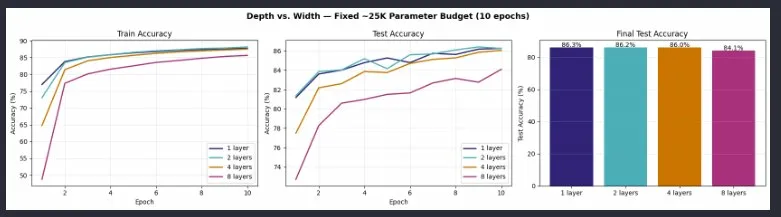
> 
> 1. La arquitectura de 1 capa logró la mejor precisión en test con 86.3%, seguida muy de cerca por 2 capas (86.2%) y 4 capas (86.0%). La de 8 capas queda rezagada con 84.1%, confirmando las dificultades de entrenar redes muy profundas sin técnicas auxiliares.
> 
> 2. Las redes de 1 y 2 capas convergieron más rápido, ambas superan el 84% ya en las primeras épocas. La de 8 capas fue la más lenta con diferencia, arrancando cerca del 50% en entrenamiento y todavía subiendo claramente al final de la época 10, señal de gradientes que se desvanecen en las capas iniciales.
> 
> 3. Sí, la red de 8 capas (84.1%) rinde de peor manera. Con ReLU simples y sin batch normalization ni conexiones residuales, los gradientes se vuelven muy pequeños antes de llegar a las primeras capas, que apenas se actualizan. Además, con anchura 26 por capa el cuello de botella de información es severo en cada capa.
>
> 4. Las brechas train-test son pequeñas en todos los modelos (1-2%), así que ninguno sobreajusta gravemente. La red de 2 capas tiene la mayor brecha (88.2% train vs 86.2% test), mientras que la de 8 capas tiene la menor en términos absolutos: no porque generalice mejor, sino porque su capacidad de memorizar el entrenamiento también está limitada por los gradientes débiles.

> **Nota sobre experimentos adicionales con más épocas**
>
> Al aumentar el número de épocas de 10, a 15, a 20 y luego a 25, las curvas de precisión en entrenamiento siguieron subiendo de forma consistente, pero las curvas de precisión en test comenzaron a oscilar significativamentem subiendo y bajando entre épocas en lugar de estabilizarse. Esto ocurre porque una vez que el modelo está cerca de su límite de capacidad, las mejoras por época son muy pequeñas y la varianza natural del proceso estocástico de entrenamiento (el orden aleatorio de los mini-batches) domina sobre la señal de aprendizaje real.
> 
> A pesar de las oscilaciones, los resultados con 25 épocas confirmaron una tendencia más clara: la red de 2 capas alcanzó el mejor test accuracy (87.8%), seguida de la de 4 capas (87.6%), mientras que la de 1 capa (86.9%) y la de 8 capas (86.3%) quedaron por debajo. Esto sugiere que con suficiente tiempo de entrenamiento la profundidad moderada sí aporta una ventaja real sobre la red puramente ancha.
> 
> Claude indica que una forma de estabilizar estas oscilaciones sería utilizar un learning rate scheduler: una técnica que reduce automáticamente la tasa de aprendizaje a medida que avanza el entrenamiento. La idea es: al principio se usa una tasa alta para aprender rápido, y conforme el modelo se acerca al mínimo se reduce la tasa para dar pasos más pequeños y precisos en lugar de rebotar alrededor de la solución. Aplicar esto podría obtener curvas de test más suaves y conclusiones más fiables.

---

## 4. Visualizing Learned Representations

A neural network doesn't just classify — it **transforms the data** layer by layer into a representation where the classes become separable. The last hidden layer's activations are the network's "internal representation" of the input, right before the final classification layer.

If a network has learned well, its last-layer embeddings should show clear cluster structure — similar items close together, different classes far apart. We can visualize this by projecting the high-dimensional embeddings to 2D using **PCA** (Principal Component Analysis).

Let's compare what the shallowest and deepest networks learned internally.

### Exercise 4.1 — Extract embeddings from the last hidden layer

Complete the function below. It should:
1. Run the input through all layers of the model **except the last one** (the classification head)
2. Return the resulting activations as a numpy array

> **Hint:** For an `nn.Sequential` model with $N$ layers, `model[:N-1]` gives you all layers except the last. But be careful — `nn.ReLU()` and `nn.Flatten()` are separate layers in the Sequential.

In [51]:
def extract_embeddings(model, loader, device):
    """Extract last hidden layer activations for all samples in loader.
    
    Args:
        model: nn.Sequential model
        loader: DataLoader
        device: torch device
    
    Returns:
        embeddings: numpy array of shape (N, D_last_hidden)
        labels: numpy array of shape (N,)
    """
    # YOUR CODE HERE
    # Hint: use model[:-1] to get all layers except the final Linear
    # Collect embeddings and labels in lists, then concatenate
    backbone = model[:-1]  
    backbone.eval()
    embeddings, labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            emb = backbone(X).cpu().numpy()
            embeddings.append(emb)
            labels.append(y.numpy())

    return np.concatenate(embeddings), np.concatenate(labels)


# Extract embeddings for the shallowest and deepest models
shallow_name = '1 layer'
deep_name = '8 layers'

emb_shallow, labels = extract_embeddings(architectures[shallow_name], test_loader, device)
emb_deep, _         = extract_embeddings(architectures[deep_name], test_loader, device)

print(f"Shallow embeddings shape: {emb_shallow.shape}")
print(f"Deep embeddings shape:    {emb_deep.shape}")

Shallow embeddings shape: (10000, 30)
Deep embeddings shape:    (10000, 26)


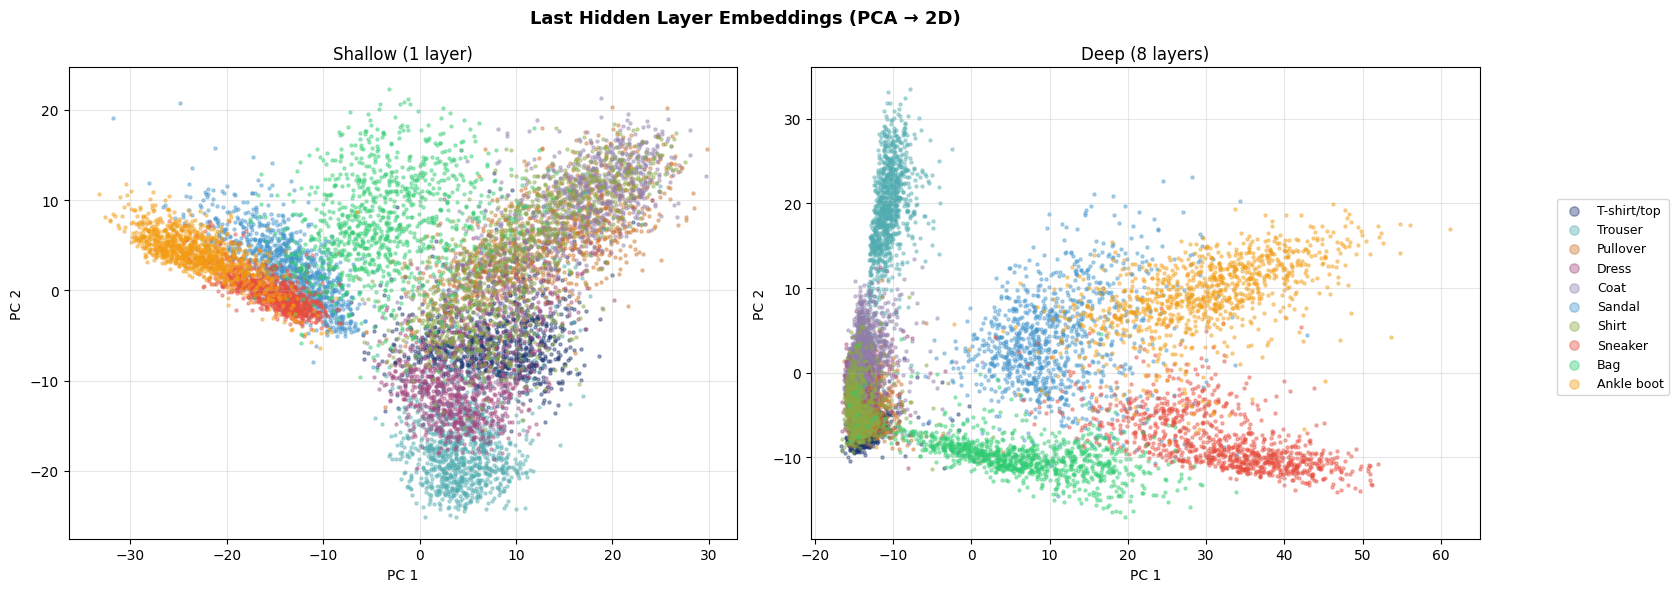

In [52]:
# PCA projection to 2D and visualization
pca_shallow = PCA(n_components=2).fit_transform(emb_shallow)
pca_deep    = PCA(n_components=2).fit_transform(emb_deep)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Color map for 10 classes
class_colors = [C1, C2, C3, C4, C5, C6, C7, '#E74C3C', '#2ECC71', '#F39C12']

for ax, pca_data, title in [(axes[0], pca_shallow, f'Shallow ({shallow_name})'),
                              (axes[1], pca_deep, f'Deep ({deep_name})')]:
    for i, name in enumerate(class_names):
        mask = labels == i
        ax.scatter(pca_data[mask, 0], pca_data[mask, 1],
                   c=class_colors[i], s=5, alpha=0.4, label=name)
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

# Shared legend
handles, legend_labels = axes[1].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='center right', bbox_to_anchor=(1.12, 0.5),
           markerscale=3, fontsize=9)

plt.suptitle('Last Hidden Layer Embeddings (PCA → 2D)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 4.1** — Comparing the embedding plots:
>
> 1. Which model produces more **separable clusters**? Are the class boundaries cleaner in the shallow or deep embedding space?
> 2. Are there classes that **overlap** in both models? Which ones? Does this match your intuition about which FashionMNIST classes are hardest to distinguish?
> 3. What does this visualization tell you about **what depth does** to the internal representation? Why does this lead to better classification?
>

> *Your answer here:*
> 1. Sorprendentemente, el modelo superficial produce una separación visualmente más limpia en el espacio PCA 2D. Su espacio de embedding de 30 dimensiones (última capa oculta más ancha) distribuye las clases en brazos radiales distintos. El espacio de 17 dimensiones del modelo profundo está más comprimido y muestra más solapamiento en el centro. Hay que tener en cuenta que PCA solo captura 2 dimensiones, el modelo profundo puede ser más separable en direcciones que PCA no muestra, lo cual es consistente con sus precisiones similares en test.
>
> 2. En ambos modelos, T-shirt/top, Pullover, Coat, Dress y Shirt se solapan considerablemente, forman la masa central densa en ambos gráficos. Esperado pues son todas prendas de la parte superior del cuerpo con siluetas similares en escala de grises. Trouser, Bag, Sneaker y Ankle boot están bien separadas en ambos modelos, por lo contrario.
>
> 3. La profundidad transforma progresivamente la representación para enfatizar las características discriminativas de clase y suprimir la variación irrelevante. Sin embargo, en este caso las capas muy estrechas del modelo profundo (ancho 17) limitan cuánta información puede fluir, razón por la que su embedding PCA aparece más comprimido. La clave es que la profundidad funciona mejor cuando las capas tienen suficiente ancho para construir representaciones intermedias significativas.

---

## Optional: Does Depth Help on Tabular Data?

In the lecture, we discussed that deep networks are especially beneficial for **structured inputs** like images — where local patterns compose into larger structures across layers. But what about **tabular data**, where features don't have spatial structure?

In Notebooks 1 and 2, we worked with the **California Housing** dataset. Let's revisit it and test whether depth helps as much here as it did on FashionMNIST.

In [21]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_h, y_h = housing.data.astype(np.float32), housing.target.astype(np.float32)
feature_names = list(housing.feature_names)

X_tr, X_te, y_tr, y_te = train_test_split(X_h, y_h, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

X_tr_t = torch.FloatTensor(X_tr)
y_tr_t = torch.FloatTensor(y_tr).unsqueeze(1)
X_te_t = torch.FloatTensor(X_te)
y_te_t = torch.FloatTensor(y_te).unsqueeze(1)

reg_train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=256, shuffle=True)
reg_test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=256)

print(f"Features : {feature_names}")
print(f"Train    : {X_tr.shape}  |  Test: {X_te.shape}")

Features : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Train    : (16512, 8)  |  Test: (4128, 8)


### Optional Exercise — Shallow vs. Deep on California Housing

Build two regression networks with **similar parameter counts** (~2K-3K parameters):
- **Shallow:** 8 → *wide* → 1 (1 hidden layer)
- **Deep:** 8 → *narrower* → *narrower* → *narrower* → 1 (3 hidden layers)

Train both with MSE loss, Adam (lr=0.001), for 30 epochs. Then compare.

In [35]:
# YOUR CODE HERE: define shallow_reg and deep_reg models
# shallow_reg = nn.Sequential(...)
# deep_reg    = nn.Sequential(...)
shallow_reg = nn.Sequential(nn.Linear(8, 256), nn.ReLU(), nn.Linear(256, 1))
deep_reg = nn.Sequential(nn.Linear(8, 45), nn.ReLU(), nn.Linear(45, 45), nn.ReLU(), nn.Linear(45, 45), nn.ReLU(), nn.Linear(45, 1))

# Verify parameter counts
print("Shallow regression:")
print(summary(shallow_reg, input_size=(1, 8), verbose=0))
print("\nDeep regression:")
print(summary(deep_reg, input_size=(1, 8), verbose=0))

Shallow regression:
Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Linear: 1-1                            [1, 256]                  2,304
├─ReLU: 1-2                              [1, 256]                  --
├─Linear: 1-3                            [1, 1]                    257
Total params: 2,561
Trainable params: 2,561
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

Deep regression:
Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Linear: 1-1                            [1, 45]                   405
├─ReLU: 1-2                              [1, 45]                   --
├─Linear: 1-3                            [1, 45]                   2,070
├─ReLU: 1-4          

In [23]:
# Train both models
criterion_reg = nn.MSELoss()
reg_results = {}

for name, model in [('Shallow', shallow_reg), ('Deep', deep_reg)]:
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses, test_losses = [], []
    for epoch in range(30):
        model.train()
        epoch_loss = 0
        for X, y in reg_train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion_reg(model(X), y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(reg_train_loader))
        
        model.eval()
        with torch.no_grad():
            te_loss = sum(criterion_reg(model(X.to(device)), y.to(device)).item()
                         for X, y in reg_test_loader) / len(reg_test_loader)
        test_losses.append(te_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"{name:>8s} | Epoch {epoch+1:2d} | Train MSE: {train_losses[-1]:.4f} | Test MSE: {test_losses[-1]:.4f}")
    
    reg_results[name] = {'train_loss': train_losses, 'test_loss': test_losses}

 Shallow | Epoch 10 | Train MSE: 0.4002 | Test MSE: 0.3978
 Shallow | Epoch 20 | Train MSE: 0.3569 | Test MSE: 0.3560
 Shallow | Epoch 30 | Train MSE: 0.3300 | Test MSE: 0.3425
    Deep | Epoch 10 | Train MSE: 0.3573 | Test MSE: 0.3562
    Deep | Epoch 20 | Train MSE: 0.3077 | Test MSE: 0.3100
    Deep | Epoch 30 | Train MSE: 0.2818 | Test MSE: 0.2869


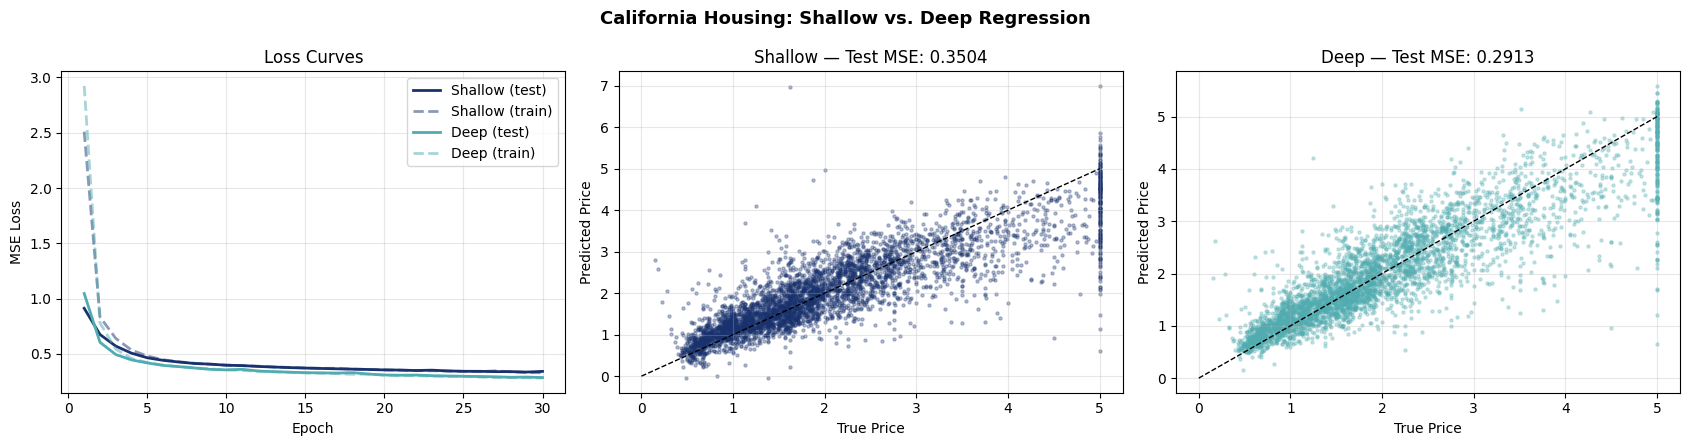

In [24]:
# Visualization: loss curves + predicted vs true
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Loss curves
for (name, hist), color in zip(reg_results.items(), [C1, C2]):
    axes[0].plot(range(1, 31), hist['test_loss'], color=color, linewidth=2, label=f'{name} (test)')
    axes[0].plot(range(1, 31), hist['train_loss'], color=color, linewidth=2,
                 linestyle='--', alpha=0.5, label=f'{name} (train)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss Curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Predicted vs true for each model
for ax, (name, model), color in zip(axes[1:], [('Shallow', shallow_reg), ('Deep', deep_reg)], [C1, C2]):
    model.eval()
    with torch.no_grad():
        preds = model(X_te_t.to(device)).cpu().numpy().flatten()
    ax.scatter(y_te, preds, s=5, alpha=0.3, color=color)
    ax.plot([0, 5], [0, 5], 'k--', linewidth=1)
    mse = np.mean((y_te - preds)**2)
    ax.set_xlabel('True Price'); ax.set_ylabel('Predicted Price')
    ax.set_title(f'{name} — Test MSE: {mse:.4f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('California Housing: Shallow vs. Deep Regression', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question O.1** — Comparing depth on images vs. tabular data:
>
> 1. Does depth help as much on California Housing as it did on FashionMNIST? Compare the relative improvement.
> 2. Why might **images** benefit more from depth than **tabular data**? Think about the structure of each input type and how layers process them.
> 3. Based on your results, when would you recommend using a deep network vs. a shallow one?
>

> *Your answer here:*
>
> 1. La profundidad sí ayuda en California Housing, y la mejora es notable dado el tamaño de los modelos. La red superficial alcanzó un MSE de test de 0.3504, mientras que la profunda llegó a 0.2913. Sin embargo hay que tomar este resultado con cautela: el modelo deep tiene 4,591 parámetros vs 2,561 del shallow, es decir casi el doble, por lo que parte de la mejora puede atribuirse simplemente a tener más parámetros y no a la profundidad en sí. Una comparación más justa requeriría igualar los parámetros.
>
> 2. Las imágenes se benefician más de la profundidad porque los píxeles tienen estructura espacial jerárquica: bordes a texturas a partes a objetos. Cada capa compone significativamente las características de la capa anterior. Las características de California Housing (ingreso mediano, edad de la vivienda, ubicación, etc.) son abstracciones ya diseñadas por humanos sin estructura espacial ni composicional (no existe un concepto significativo de "un borde compuesto por valores de ingresos"). Una sola capa puede capturar las interacciones no lineales relevantes casi tan bien como muchas capas.
>
> 3. Usaría una red profunda cuando las entradas tienen estructura espacial, temporal o jerárquica (imágenes, audio, texto). Mientras que usaría una red superficial o moderadamente profunda para datos tabulares, ya que las ganancias de la profundidad son menores, el entrenamiento es más simple, y en la práctica los árboles con gradient boosting (XGBoost, LightGBM) suelen superar a ambas. Si es necesario usar una red neuronal con datos tabulares, 2–3 capas debería alcanzar.